In [42]:
# install.packages("tidyverse")
library(tidyverse)
# install.packages("ggplot2")
library(ggplot2)
# install.packages("dplyr")
library(dplyr)
# install.packages("tidyr")
library(tidyr)
# install.packages("gmodels")
library(gmodels)
# install.packages("matrixStats")
library(matrixStats)
# install.packages("corrplot")
library(corrplot)
# install.packages("MASS")
library(MASS)

### 1. Importação de Dados através de [InsideAirbnb](https://insideairbnb.com/get-the-data/) -> Tasmania

In [43]:
dados <- read.csv("listings.csv", stringsAsFactors = TRUE)
head(dados)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
,<dbl>,<fct>,<int>,<fct>,<lgl>,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<int>,<int>,<int>,<fct>
1,35644,Central Hobart Historic Cottage,153268,Yvette,NA,Hobart,-42.87895,147.3153,Private room,NA,1,255,2020-03-08,1.64,3,0,0,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
2,88873,Terrace- 5mins to central Hobart,485048,Russell And Ingrid,NA,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,2025-09-04,3.83,1,147,50,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
3,137808,Bradman House CBD Launceston Invermay + Free WIFI,673625,Emma And Dale,NA,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2025-09-09,2.79,2,287,49,DA0518/2019
4,268482,"Anderson Suite, The Ark Stanley, Guest House",1406692,Rhonda,NA,Circular Head,-40.76490,145.2970,Private room,344,1,5,2025-01-02,0.06,7,286,1,
5,292399,"Rainbow Valley Retreat, Ellendale",1513972,Mandy,NA,Central Highlands,-42.62103,146.7157,Private room,120,1,248,2025-06-09,1.60,1,362,26,
6,292447,"Rustic, compact, family friendly...",1514295,Bernd,NA,Hobart,-42.86919,147.3000,Private room,48,2,160,2025-08-03,1.03,1,348,14,Exempt: This listing falls under the 'home sharing' exemption


In [44]:
str(dados)

'data.frame':	6501 obs. of  18 variables:
 $ id                            : num  35644 88873 137808 268482 292399 ...
 $ name                          : Factor w/ 6447 levels "''Birch Lane''  Self- Contained B&B, Cradoc/Cygnet",..: 1307 5297 1085 455 4182 4463 1866 2736 5806 4782 ...
 $ host_id                       : int  153268 485048 673625 1406692 1513972 1514295 1670767 1777929 2404373 2417230 ...
 $ host_name                     : Factor w/ 1656 levels "Aaron","Aaron And Emma",..: 1644 1333 453 1276 990 158 733 657 1473 77 ...
 $ neighbourhood_group           : logi  NA NA NA NA NA NA ...
 $ neighbourhood                 : Factor w/ 29 levels "Break O'Day",..: 15 15 21 6 5 15 14 19 21 27 ...
 $ latitude                      : num  -42.9 -42.9 -41.4 -40.8 -42.6 ...
 $ longitude                     : num  147 147 147 145 147 ...
 $ room_type                     : Factor w/ 4 levels "Entire home/apt",..: 3 1 1 3 3 3 1 3 1 1 ...
 $ price                         : int  NA 113 245 344

### 2. Limpeza de Dados

In [46]:
# Cópia de dados para limpeza
df <- dados

# Remoção de colunas não necessárias para o Modelo
df <- dplyr::select(df, -id, -name, -host_id, -host_name, -neighbourhood_group, -license, -last_review)

# Remoção de linhas com 'NA' em 'price' <- varíavel alvo
df <- df %>% drop_na(price)

# Se um listing tem 'NA' reviews é porque não tem reviews (0)
df$reviews_per_month[is.na(df$reviews_per_month)] <- 0

# 'price' tem de ser 'num', não pode ser 'int'
df$price <- as.numeric(df$price)

In [47]:
str(df)
summary(df)

'data.frame':	5666 obs. of  11 variables:
 $ neighbourhood                 : Factor w/ 29 levels "Break O'Day",..: 15 21 6 5 15 14 21 27 1 15 ...
 $ latitude                      : num  -42.9 -41.4 -40.8 -42.6 -42.9 ...
 $ longitude                     : num  147 147 145 147 147 ...
 $ room_type                     : Factor w/ 4 levels "Entire home/apt",..: 1 1 3 3 3 1 1 1 1 1 ...
 $ price                         : num  113 245 344 120 48 223 311 390 315 210 ...
 $ minimum_nights                : int  2 1 1 1 2 2 2 2 2 1 ...
 $ number_of_reviews             : int  668 461 5 248 160 59 481 80 96 23 ...
 $ reviews_per_month             : num  3.83 2.79 0.06 1.6 1.03 0.5 3.12 0.55 0.66 0.45 ...
 $ calculated_host_listings_count: int  1 2 7 1 1 1 2 1 28 7 ...
 $ availability_365              : int  147 287 286 362 348 244 335 299 315 326 ...
 $ number_of_reviews_ltm         : int  50 49 1 26 14 5 52 2 6 9 ...


              neighbourhood     latitude        longitude    
 Hobart              :1082   Min.   :-43.58   Min.   :143.8  
 Launceston          : 592   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 522   Median :-42.15   Median :147.3  
 Kingborough         : 415   Mean   :-42.14   Mean   :147.2  
 Clarence            : 380   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 339   Max.   :-39.69   Max.   :148.3  
 (Other)             :2336                                   
           room_type        price         minimum_nights    number_of_reviews
 Entire home/apt:5081   Min.   :   32.0   Min.   :  1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:  150.0   1st Qu.:  1.000   1st Qu.:  13.0   
 Private room   : 526   Median :  198.0   Median :  2.000   Median :  47.0   
 Shared room    :   0   Mean   :  242.6   Mean   :  1.936   Mean   : 101.0   
                        3rd Qu.:  275.0   3rd Qu.:  2.000   3rd Qu.: 130.8   
                        Max.   :1510

In [48]:
unique(df$room_type)
print("Contagem de cada tipo de quarto no df pré limpeza de NA's:")
table(dados$room_type)

# 'room_type' tem 4 níveis, mas só 3 são relevantes para o nosso modelo (então vamos eliminar o Shared Room, que ficou com 0 valores)
df$room_type <- droplevels(df$room_type)

print("Contagem de cada tipo de quarto no df pós limpeza de NA's:")
table(df$room_type)

[1] Entire home/apt Private room    Hotel room     
Levels: Entire home/apt Hotel room Private room Shared room

[1] "Contagem de cada tipo de quarto no df pré limpeza de NA's:"



Entire home/apt      Hotel room    Private room     Shared room 
           5721              81             698               1 

[1] "Contagem de cada tipo de quarto no df pós limpeza de NA's:"



Entire home/apt      Hotel room    Private room 
           5081              59             526 

In [49]:
# Vamos verificar se o mesmo aconteceu em neighbourhood
table(df$neighbourhood)


         Break O'Day             Brighton               Burnie 
                 339                   11                   53 
       Central Coast    Central Highlands        Circular Head 
                 141                   65                  131 
            Clarence       Derwent Valley            Devonport 
                 380                   75                  104 
              Dorset             Flinders          George Town 
                 181                   29                   62 
Glamorgan/Spring Bay            Glenorchy               Hobart 
                 522                  118                 1082 
         Huon Valley              Kentish          King Island 
                 219                  107                   42 
         Kingborough              Latrobe           Launceston 
                 415                   72                  592 
      Meander Valley    Northern Midlands               Sorell 
                 111                   

In [50]:
# Teto máximo de minimum_nights para eliminar outliers

df <- df %>% 
  filter(minimum_nights <= 22)

In [51]:
# Eliminação de outlier com preço de 15.000$ por noite

limite_superior <- quantile(df$price, 0.99)
df <- df[df$price <= limite_superior, ]

In [52]:
# Verificação final dos dados para ver se está tudo OK
head(df)
summary(df)

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>
1,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,3.83,1,147,50
2,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2.79,2,287,49
3,Circular Head,-40.76490,145.2970,Private room,344,1,5,0.06,7,286,1
4,Central Highlands,-42.62103,146.7157,Private room,120,1,248,1.60,1,362,26
5,Hobart,-42.86919,147.3000,Private room,48,2,160,1.03,1,348,14
6,Glenorchy,-42.77935,147.2560,Entire home/apt,223,2,59,0.50,1,244,5


              neighbourhood     latitude        longitude    
 Hobart              :1065   Min.   :-43.58   Min.   :143.8  
 Launceston          : 583   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 514   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2305                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5008   Min.   : 36.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  58   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 522   Median :197.0   Median : 2.000   Median :  48.0   
                        Mean   :227.5   Mean   : 1.765   Mean   : 102.1   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 133.0   
                        Max.   :940.0   Max.   :21.000

### 3. Exploração dos Dados

#### Distribuição de Preço (Price)

O histograma é _right-skewed_, dado que existem propriedades de luxo - _outliers_ - com preços por noite bastante acima da média 

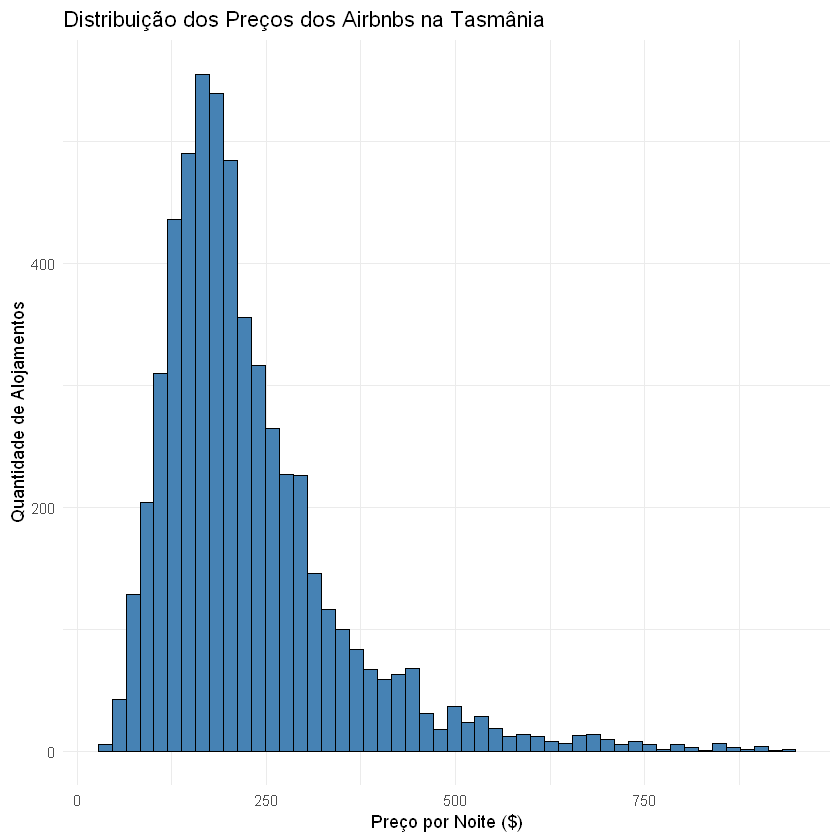

In [53]:
ggplot(df, aes(x = price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuição dos Preços dos Airbnbs na Tasmânia",
       x = "Preço por Noite ($)",
       y = "Quantidade de Alojamentos")

### Preço vs Tipo de Quarto

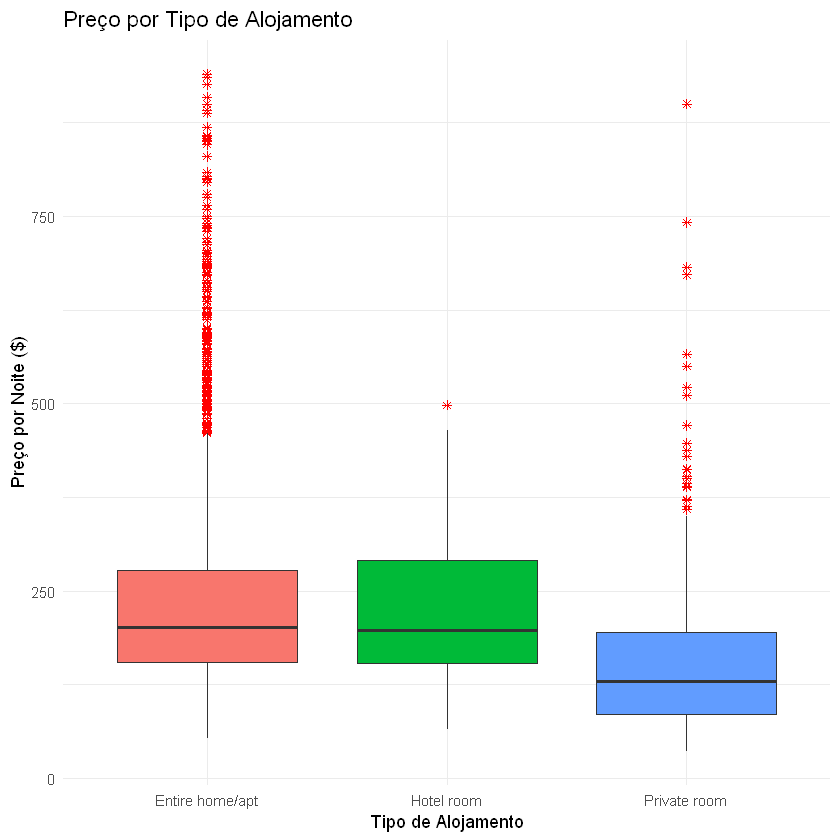

In [54]:
ggplot(df, aes(x = room_type, y = price, fill = room_type)) +
  geom_boxplot(outlier.color = "red", outlier.shape = 8) +
  theme_minimal() +
  labs(title = "Preço por Tipo de Alojamento",
       x = "Tipo de Alojamento",
       y = "Preço por Noite ($)") +
  theme(legend.position = "none")

### Visuaização das propriedades em coordenadas

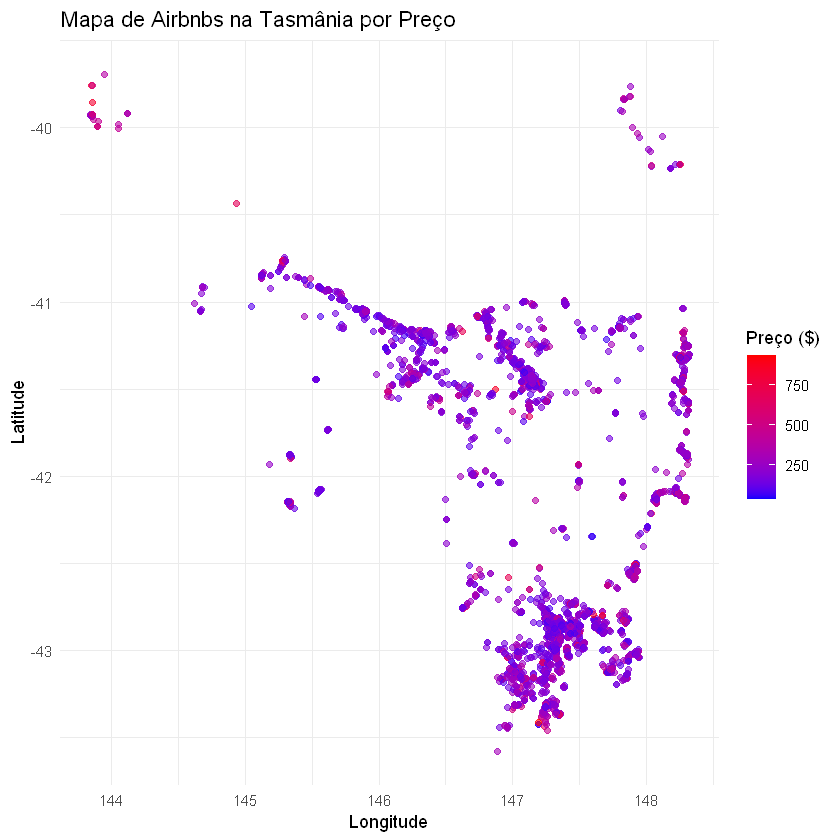

In [55]:
ggplot(df, aes(x = longitude, y = latitude, color = price)) +
  geom_point(alpha = 0.6, size = 1.5) + 
  scale_color_gradient(low = "blue", high = "red") + # Baratos a azul, Caros a vermelho
  theme_minimal() +
  labs(title = "Mapa de Airbnbs na Tasmânia por Preço",
       x = "Longitude",
       y = "Latitude",
       color = "Preço ($)")

### Disponibilidade 365 dias vs Preço

`geom_smooth()` using formula = 'y ~ x'


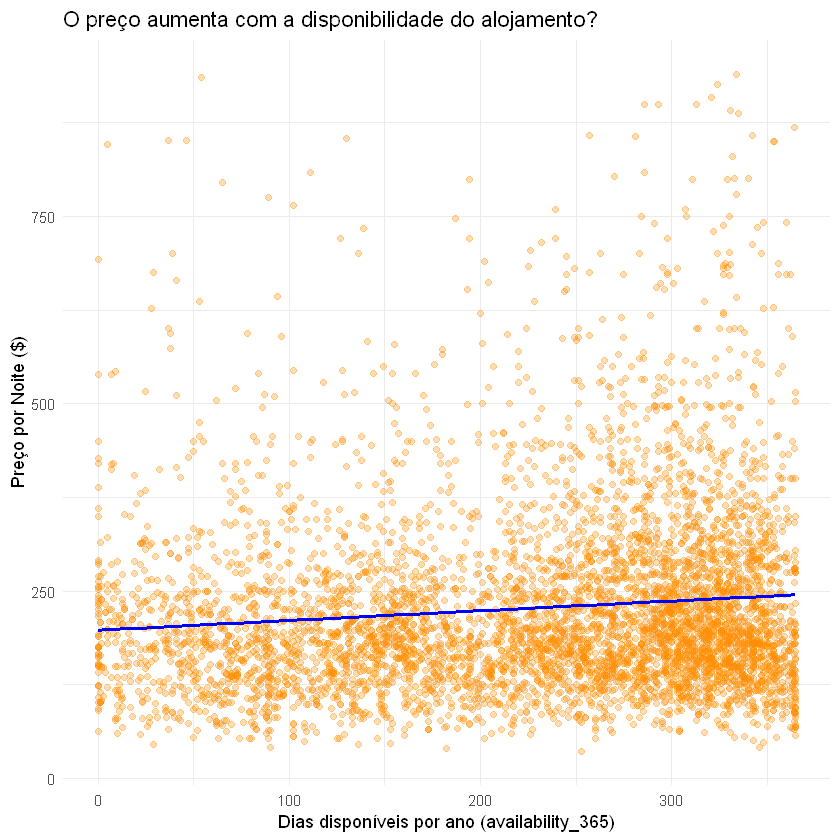

In [56]:
ggplot(df, aes(x = availability_365, y = price)) +
  geom_point(alpha = 0.3, color = "darkorange") +
  geom_smooth(method = "lm", color = "blue", se = FALSE) + 
  theme_minimal() +
  labs(title = "O preço aumenta com a disponibilidade do alojamento?",
       x = "Dias disponíveis por ano (availability_365)",
       y = "Preço por Noite ($)")

### Top 10 Bairros com mais Airbnbs

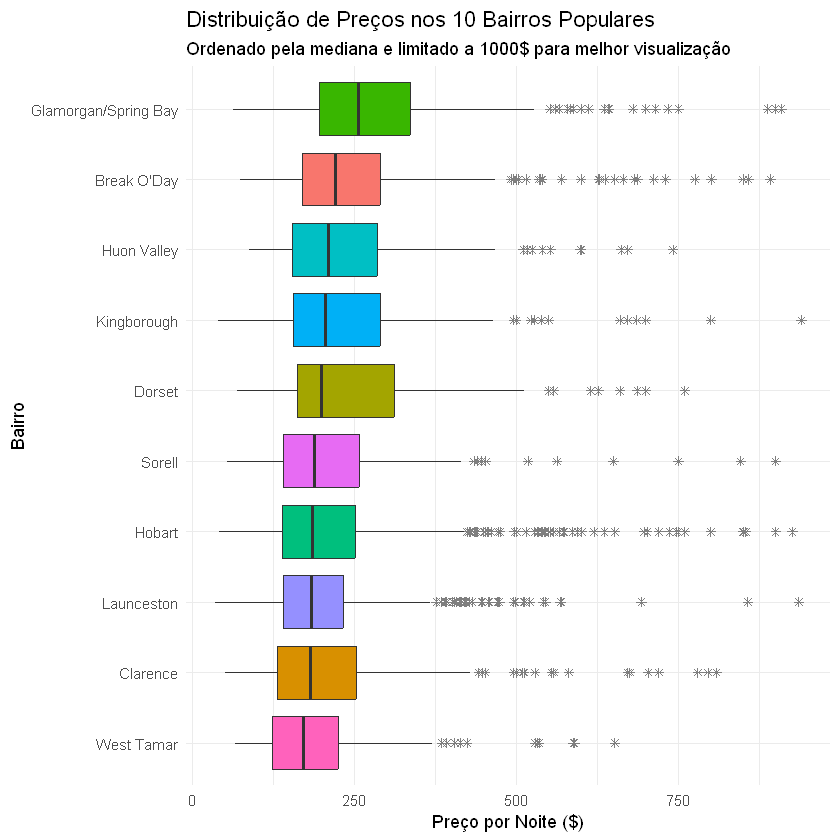

In [57]:
top_10_bairros <- df %>%
  as_tibble() %>% # as_tibble para garantir que o R entende que isto é uma tabela de dados
  dplyr::count(neighbourhood, sort = TRUE) %>%
  head(10) %>%
  dplyr::pull(neighbourhood)

df %>%
  dplyr::filter(neighbourhood %in% top_10_bairros) %>%
  ggplot(aes(x = reorder(neighbourhood, price, FUN = median), y = price, fill = neighbourhood)) +
  geom_boxplot(outlier.color = "gray50", outlier.shape = 8) +
  coord_flip() + 
  theme_minimal() +
  labs(title = "Distribuição de Preços nos 10 Bairros Populares",
       subtitle = "Ordenado pela mediana e limitado a 1000$ para melhor visualização",
       x = "Bairro",
       y = "Preço por Noite ($)") +
  theme(legend.position = "none")

### Distribuição do número mínimo de noites

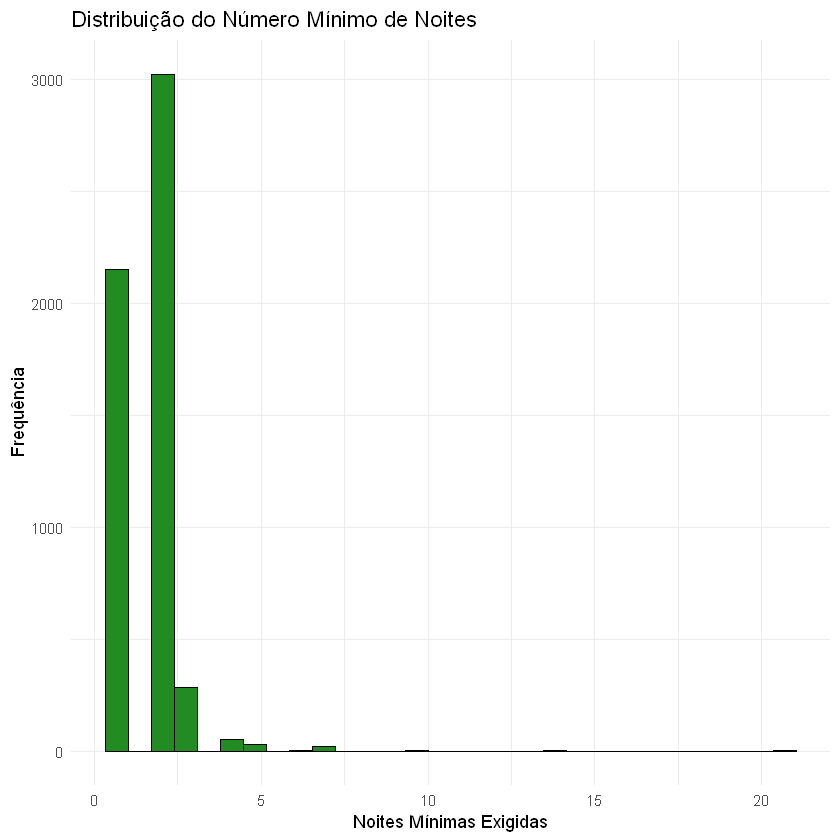

In [58]:
ggplot(df, aes(x = minimum_nights)) +
  geom_histogram(fill = "forestgreen", color = "black", bins = 30) +
  theme_minimal() +
  labs(title = "Distribuição do Número Mínimo de Noites",
       x = "Noites Mínimas Exigidas",
       y = "Frequência")

### 4. Correlação de Variáveis

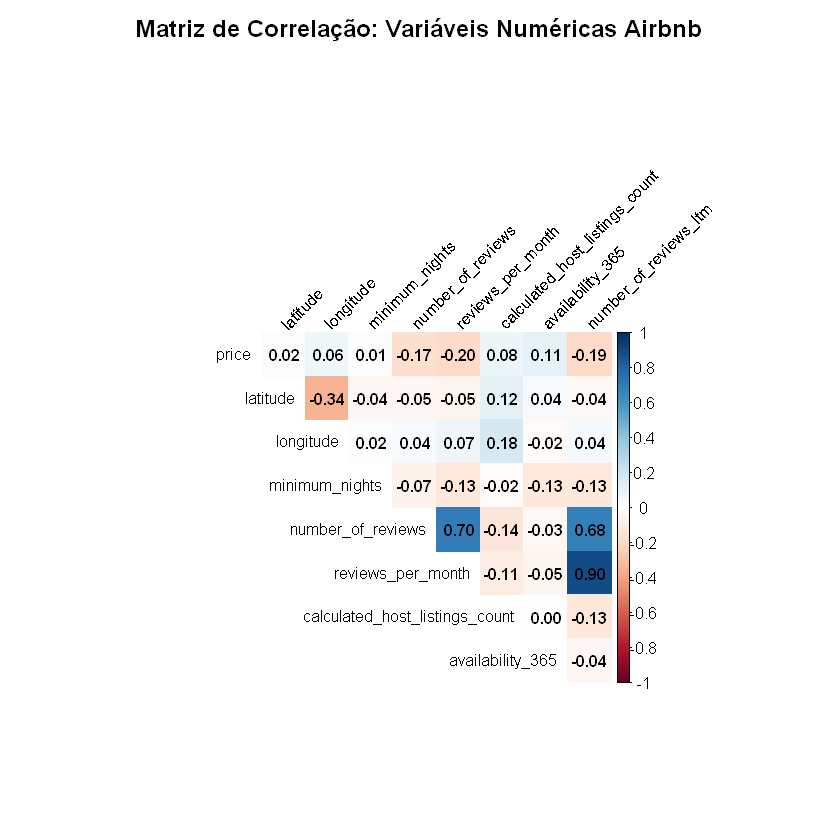

In [59]:
df_numeric <- df %>%
  dplyr::select(price, latitude, longitude, minimum_nights, 
                number_of_reviews, reviews_per_month, 
                calculated_host_listings_count, availability_365, 
                number_of_reviews_ltm)

matriz_cor <- cor(df_numeric, use = "complete.obs")

par(mar = c(1, 1, 3, 1)) 

corrplot(matriz_cor, 
         method = "color", 
         type = "upper", 
         addCoef.col = "black", 
         number.cex = 0.8,      # Números ligeiramente maiores para ler bem
         tl.col = "black", 
         tl.srt = 45, 
         tl.cex = 0.8, 
         diag = FALSE)

# Adicionar o título manualmente para controlar a distância
title("Matriz de Correlação: Variáveis Numéricas Airbnb", line = 1.5, cex.main = 1.2)

### 5. Feature Engineering

In [60]:
# Como as 3 colunas de reviews estão altamente correlacionadas, vamos manter só a 'number_of_reviews' e eliminar as outras 2 para evitar multicolinearidade no modelo
df <- df %>%
  dplyr::select(-reviews_per_month, -number_of_reviews_ltm)
names(df)

[1] "neighbourhood"                  "latitude"                      
[3] "longitude"                      "room_type"                     
[5] "price"                          "minimum_nights"                
[7] "number_of_reviews"              "calculated_host_listings_count"
[9] "availability_365"

In [61]:
# Transformação de preço em log para lidar com a assimetria e outliers
df <- df %>%
  mutate(log_price = log(price))

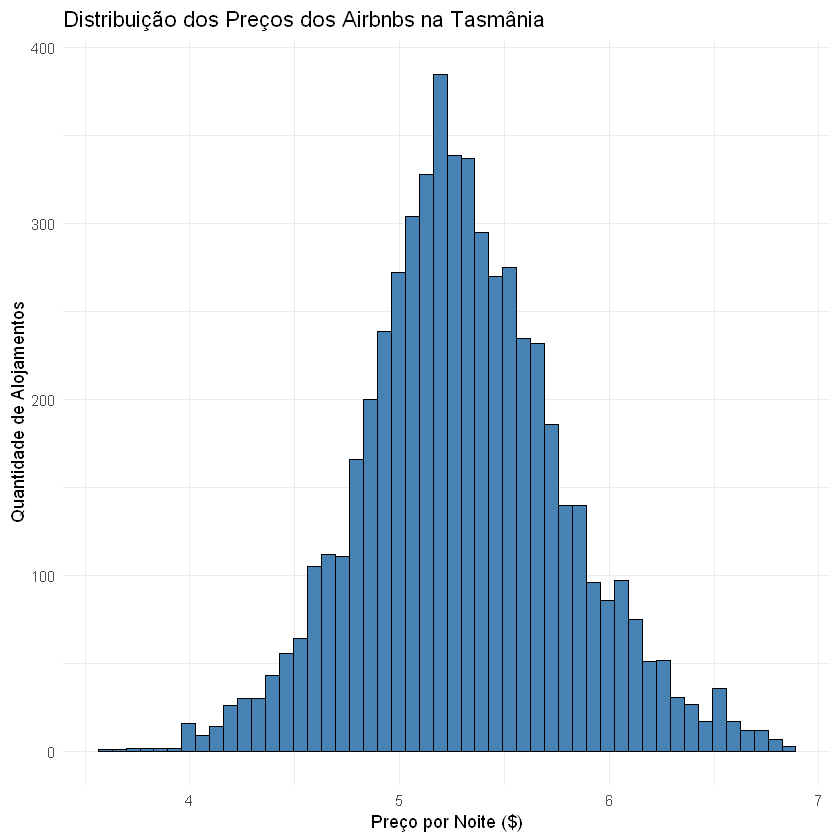

In [62]:
# Visualização da distribuição do preço após transformação logarítmica
ggplot(df, aes(x = log_price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuição dos Preços dos Airbnbs na Tasmânia",
       x = "Preço por Noite ($)",
       y = "Quantidade de Alojamentos")